### 1. ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요. 


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from torchvision import models, datasets
from torchvision.transforms import transforms

import subprocess, logging, warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설치 및 직접 등록
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
for font_path in [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf",
]:
    try:
        fm.fontManager.addfont(font_path)
    except Exception:
        pass

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message='Glyph .* missing from font')


In [10]:
# 데이터셋 불러오기 - CIFAR-10
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train = datasets.CIFAR10(root='./data',
                         train=True,
                         transform=transform_base,
                         download=True)

test = datasets.CIFAR10(root='./data',
                        train=False,
                        transform=transform_base,
                        download=True)

In [11]:
# 데이터 로더
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=64, shuffle=False)

In [12]:
# pretrained ResNet50 모델 로드
base_model = models.resnet50(weights=None)
base_model = nn.Sequential(*list(base_model.children())[:-2]) # GlobalAveragePooling을 위해 마지막 두 레이어 제거

In [13]:
# 모델 구조 확인
print(base_model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [14]:
class CustomResNet50(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet50, self).__init__()
        self.base_model = base_model
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(2048, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.base_model(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

resnet_model = CustomResNet50(num_classes=10)

In [ ]:
# 방금 만든 resnet_model에 더미 입력을 넣어 차원 흐름을 직접 확인
dummy = torch.zeros(1, 3, 32, 32)
resnet_model.eval()

with torch.no_grad():
    x = dummy
    print(f"[입력]             {list(x.shape)}")

    x = resnet_model.base_model(x)
    print(f"[base_model 출력]  {list(x.shape)} - ResNet50 마지막 Conv 블록 (채널=2048)")

    x = resnet_model.global_avg_pool(x)
    print(f"[global_avg_pool] {list(x.shape)} - H,W 강제로 1×1")

    x = torch.flatten(x, 1)
    print(f"[flatten]         {list(x.shape)} - fc1 in_features = {x.shape[1]}")

    x = resnet_model.fc1(x)
    print(f"[fc1]             {list(x.shape)}")

    x = resnet_model.relu(x)
    x = resnet_model.fc2(x)
    print(f"[fc2 (최종 출력)]  {list(x.shape)} - 10 클래스")

[입력]             [1, 3, 32, 32]
[base_model 출력]  [1, 2048, 1, 1] - ResNet50 마지막 Conv 블록 (채널=2048)
[global_avg_pool] [1, 2048, 1, 1] - H,W 강제로 1×1
[flatten]         [1, 2048] - fc1 in_features = 2048
[fc1]             [1, 256]
[fc2 (최종 출력)]  [1, 10] - 10 클래스


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

In [17]:
num_epochs = 10
resnet_losses = []

for epoch in range(num_epochs):
    resnet_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    resnet_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}')

Epoch 1, Loss: 2.2003
Epoch 2, Loss: 2.1249
Epoch 3, Loss: 2.0787
Epoch 4, Loss: 2.0487
Epoch 5, Loss: 2.0180
Epoch 6, Loss: 2.0057
Epoch 7, Loss: 1.9939
Epoch 8, Loss: 1.9746
Epoch 9, Loss: 1.9690
Epoch 10, Loss: 1.9544


In [18]:
resnet_model.eval()
correct = 0
total = 0
class_correct_resnet = [0] * 10
class_total_resnet   = [0] * 10

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            class_correct_resnet[labels[i]] += (predicted[i] == labels[i]).item()
            class_total_resnet[labels[i]]   += 1

resnet_accuracy = correct / total
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
resnet_class_acc = [
    class_correct_resnet[i] / class_total_resnet[i] if class_total_resnet[i] > 0 else 0
    for i in range(10)
]

print(f'ResNet50 Test Accuracy: {resnet_accuracy * 100:.2f}%')
for cls, acc in zip(classes, resnet_class_acc):
    print(f'  {cls:12s}: {acc*100:.1f}%')

ResNet50 Test Accuracy: 48.50%
  airplane    : 63.1%
  automobile  : 63.5%
  bird        : 30.0%
  cat         : 39.6%
  deer        : 31.3%
  dog         : 37.6%
  frog        : 59.2%
  horse       : 64.0%
  ship        : 45.6%
  truck       : 51.1%


### 2. 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요. 

In [19]:
## VGG16 모델 로드 
base_model = models.vgg16(weights=None)

In [20]:
# 모델 구조 확인
print(base_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [21]:
class CustomVGG16(nn.Module):
    def __init__(self, num_classes):
        super(CustomVGG16, self).__init__()
        self.base_model = base_model
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

vgg_model = CustomVGG16(num_classes=10)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=0.0001)

In [23]:
num_epochs = 10
vgg_losses = []

for epoch in range(num_epochs):
    vgg_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = vgg_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    vgg_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}')

Epoch 1, Loss: 2.2001
Epoch 2, Loss: 2.1187
Epoch 3, Loss: 2.0751
Epoch 4, Loss: 2.0601
Epoch 5, Loss: 2.0455
Epoch 6, Loss: 2.0223
Epoch 7, Loss: 2.0073
Epoch 8, Loss: 2.0195
Epoch 9, Loss: 2.0082
Epoch 10, Loss: 2.0057


In [24]:
vgg_model.eval()
correct = 0
total = 0
class_correct_vgg = [0] * 10
class_total_vgg   = [0] * 10

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = vgg_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            class_correct_vgg[labels[i]] += (predicted[i] == labels[i]).item()
            class_total_vgg[labels[i]]   += 1

vgg_accuracy = correct / total
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
vgg_class_acc = [
    class_correct_vgg[i] / class_total_vgg[i] if class_total_vgg[i] > 0 else 0
    for i in range(10)
]

print(f'VGG16 Test Accuracy: {vgg_accuracy * 100:.2f}%')
for cls, acc in zip(classes, vgg_class_acc):
    print(f'  {cls:12s}: {acc*100:.1f}%')

VGG16 Test Accuracy: 47.48%
  airplane    : 46.8%
  automobile  : 85.0%
  bird        : 3.7%
  cat         : 29.1%
  deer        : 38.0%
  dog         : 37.7%
  frog        : 76.9%
  horse       : 50.1%
  ship        : 64.7%
  truck       : 42.8%


### 3. 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요. 

In [25]:
# 파라미터 수 비교 
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

r_total, r_train = count_params(resnet_model)
v_total, v_train = count_params(vgg_model)

print(f"{'모델':<12} {'전체 파라미터':>16} {'학습 가능':>16}")
print("─" * 47)
print(f"{'ResNet50':<12} {r_total:>16,} {r_train:>16,}")
print(f"{'VGG16':<12} {v_total:>16,} {v_train:>16,}")

모델                    전체 파라미터            학습 가능
───────────────────────────────────────────────
ResNet50           24,035,146       24,035,146
VGG16             138,491,442      138,491,442


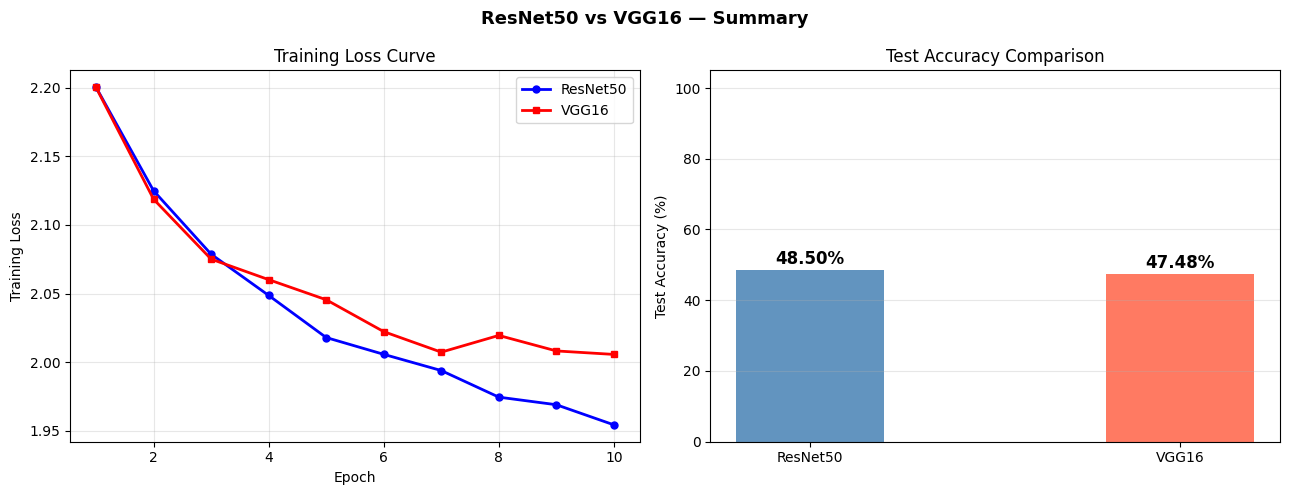


ResNet50: 48.50%  |  VGG16: 47.48%  |  차이: +1.02%p


In [28]:
# 학습 Loss 곡선 + 전체 정확도 비교 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 좌: Loss 곡선
ax1 = axes[0]
if resnet_losses:
    ax1.plot(range(1, len(resnet_losses) + 1), resnet_losses,
             'b-o', label='ResNet50', markersize=5, linewidth=2)
if vgg_losses:
    ax1.plot(range(1, len(vgg_losses) + 1), vgg_losses,
             'r-s', label='VGG16', markersize=5, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 우: 정확도 막대 차트
ax2 = axes[1]
accs = [resnet_accuracy * 100, vgg_accuracy * 100]
bars = ax2.bar(['ResNet50', 'VGG16'], accs,
               color=['steelblue', 'tomato'], width=0.4, alpha=0.85)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Comparison')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('ResNet50 vs VGG16 — Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nResNet50: {resnet_accuracy*100:.2f}%  |  VGG16: {vgg_accuracy*100:.2f}%  |  차이: {(resnet_accuracy-vgg_accuracy)*100:+.2f}%p")

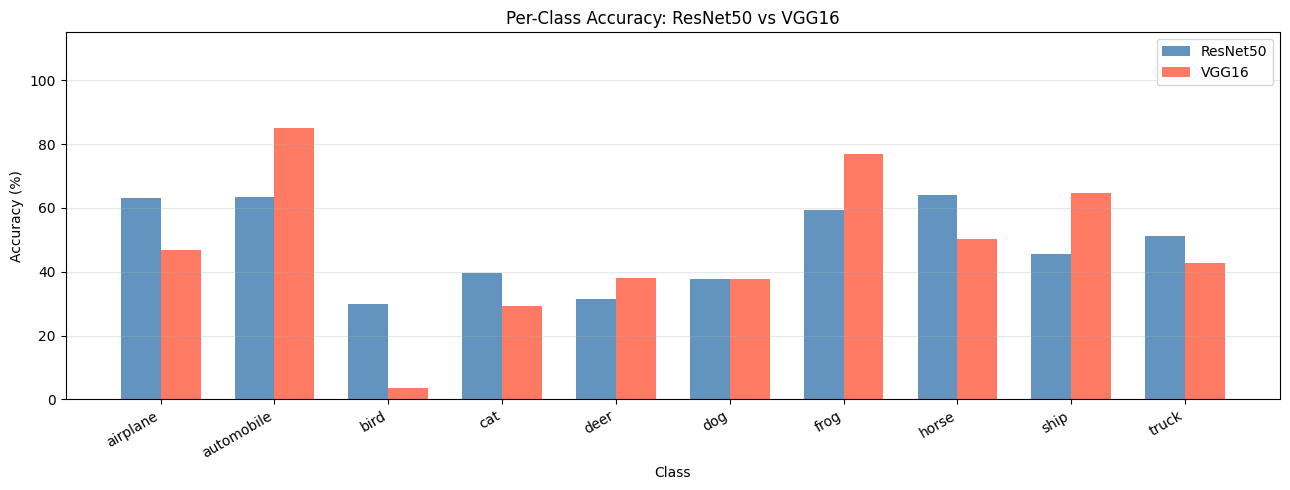


클래스              ResNet50      VGG16    차이(R-V)
────────────────────────────────────────────────
airplane            63.1%      46.8% +   16.3%
automobile          63.5%      85.0%   -21.5%
bird                30.0%       3.7% +   26.3%
cat                 39.6%      29.1% +   10.5%
deer                31.3%      38.0%    -6.7%
dog                 37.6%      37.7%    -0.1%
frog                59.2%      76.9%   -17.7%
horse               64.0%      50.1% +   13.9%
ship                45.6%      64.7%   -19.1%
truck               51.1%      42.8% +    8.3%


In [29]:
# 클래스별 정확도 비교 
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
x_pos = range(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x_pos], [a * 100 for a in resnet_class_acc],
       width, label='ResNet50', color='steelblue', alpha=0.85)
ax.bar([i + width/2 for i in x_pos], [a * 100 for a in vgg_class_acc],
       width, label='VGG16', color='tomato', alpha=0.85)
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: ResNet50 vs VGG16')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n{'클래스':<14} {'ResNet50':>10} {'VGG16':>10} {'차이(R-V)':>10}")
print("─" * 48)
for cls, r_acc, v_acc in zip(classes, resnet_class_acc, vgg_class_acc):
    diff = (r_acc - v_acc) * 100
    sign = '+' if diff >= 0 else ''
    print(f"{cls:<14} {r_acc*100:>9.1f}% {v_acc*100:>9.1f}% {sign}{diff:>7.1f}%")

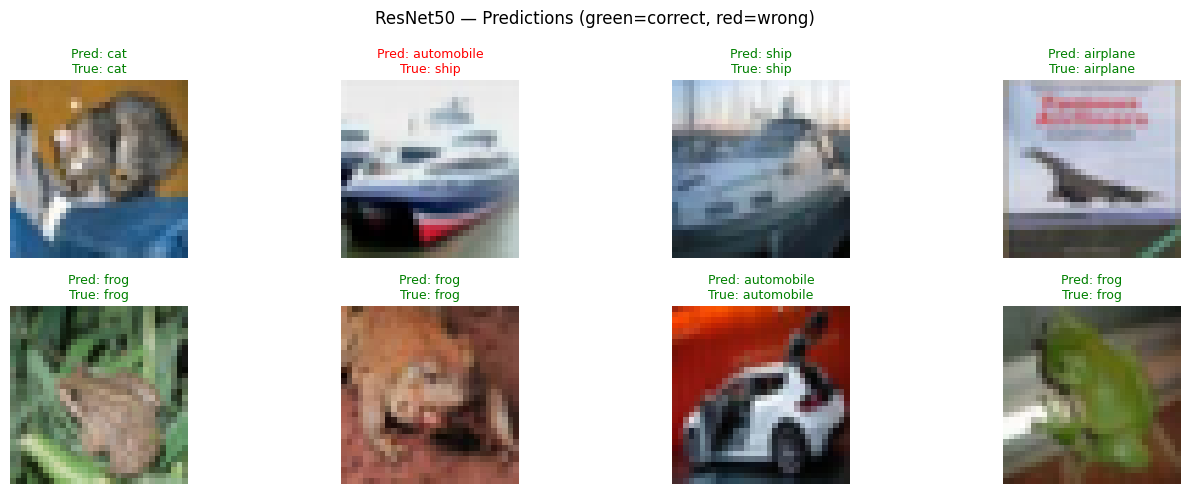

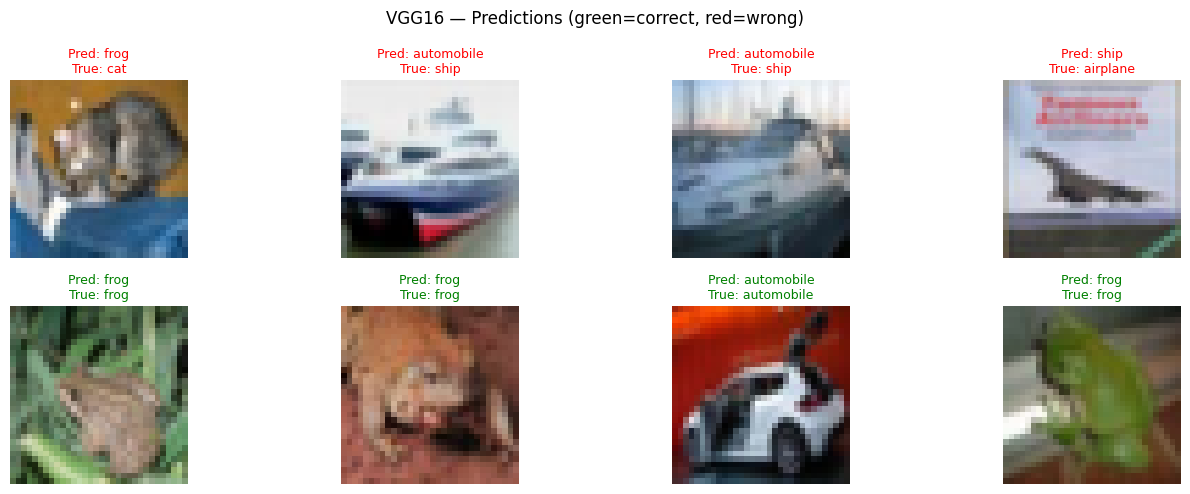

In [ ]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def show_predictions(model, model_name, loader, n=8):
    model.eval()
    images, labels = next(iter(loader))
    images_show = images[:n]
    labels_show = labels[:n]

    with torch.no_grad():
        outputs = model(images_show)
        _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 5))
    axes = axes.flatten()
    for i in range(n):
        img = images_show[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i].imshow(img.clip(0, 1))
        color = 'green' if preds[i] == labels_show[i] else 'red'
        axes[i].set_title(
            f'Pred: {classes[preds[i]]}\nTrue: {classes[labels_show[i]]}',
            color=color, fontsize=9
        )
        axes[i].axis('off')
    fig.suptitle(f'{model_name} — Predictions (green=correct, red=wrong)', fontsize=12)
    plt.tight_layout()
    plt.show()

show_predictions(resnet_model, 'ResNet50', test_loader)
show_predictions(vgg_model,    'VGG16',    test_loader)


### 4. 가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요.  

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from scipy.stats import randint
import pandas as pd
import seaborn as sns

In [ ]:
# 데이터 준비
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model_gs = grid_search.best_estimator_
gs_train_acc = best_model_gs.score(X_train, y_train)
gs_test_acc  = best_model_gs.score(X_test,  y_test)

print('Best params:', grid_search.best_params_)
print(f'Train Accuracy: {gs_train_acc:.4f}  |  Test Accuracy: {gs_test_acc:.4f}')


Best params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Train Accuracy: 0.9637  |  Test Accuracy: 0.9250


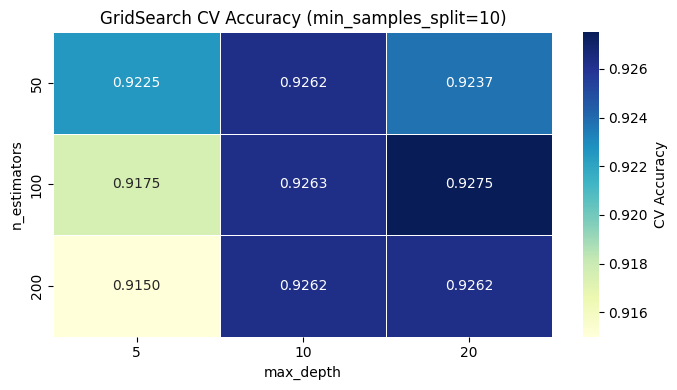

In [ ]:
# GridSearch 결과 히트맵
gs_df = pd.DataFrame(grid_search.cv_results_)
best_split = grid_search.best_params_['min_samples_split']
subset = gs_df[gs_df['param_min_samples_split'] == best_split]
pivot = subset.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
ax.set_title(f'GridSearch CV Accuracy (min_samples_split={best_split})')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
plt.tight_layout()
plt.show()


In [ ]:
# RandomSearch
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 25),
    'min_samples_split': randint(2, 20)
}

model = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=20, cv=5, scoring='accuracy',
                                   random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_rs = random_search.best_estimator_
rs_train_acc = best_model_rs.score(X_train, y_train)
rs_test_acc  = best_model_rs.score(X_test,  y_test)

print('Best params:', random_search.best_params_)
print(f'Train Accuracy: {rs_train_acc:.4f}  |  Test Accuracy: {rs_test_acc:.4f}')


Best params: {'max_depth': 17, 'min_samples_split': 13, 'n_estimators': 104}
Train Accuracy: 0.9500  |  Test Accuracy: 0.9250


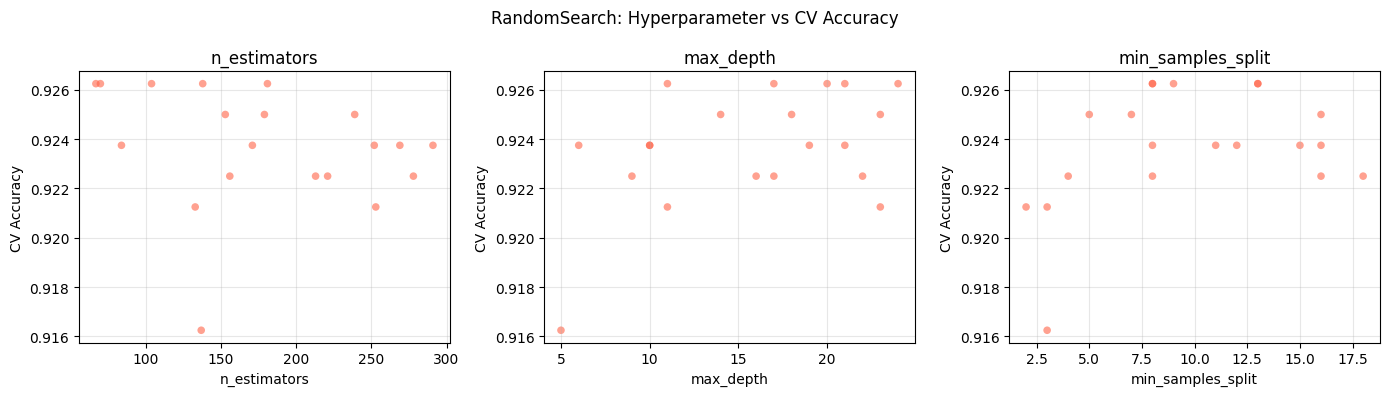

In [ ]:
# RandomSearch: parameter vs CV accuracy
rs_df = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
param_cols = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split']
labels     = ['n_estimators', 'max_depth', 'min_samples_split']

for ax, col, label in zip(axes, param_cols, labels):
    ax.scatter(rs_df[col].astype(int), rs_df['mean_test_score'],
               alpha=0.6, s=30, color='tomato', edgecolors='none')
    ax.set_xlabel(label)
    ax.set_ylabel('CV Accuracy')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('RandomSearch: Hyperparameter vs CV Accuracy', fontsize=12)
plt.tight_layout()
plt.show()


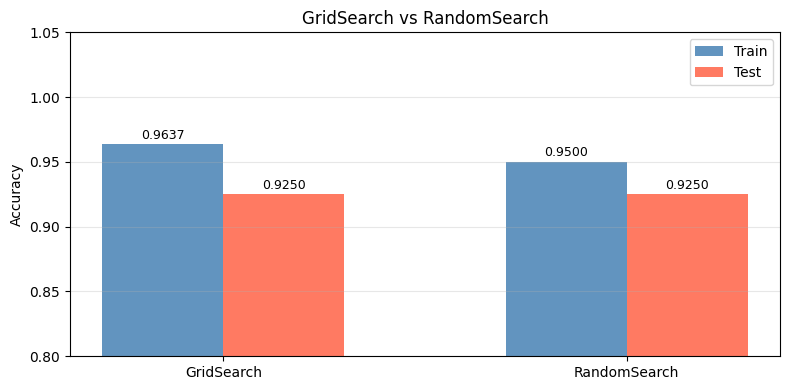

GridSearch   — 탐색 횟수:  27,  Best CV: 0.9275,  Test: 0.9250
RandomSearch — 탐색 횟수:  20,  Best CV: 0.9263,  Test: 0.9250


In [ ]:
# GridSearch vs RandomSearch 최종 비교
fig, ax = plt.subplots(figsize=(8, 4))
methods = ['GridSearch', 'RandomSearch']
train_accs = [gs_train_acc, rs_train_acc]
test_accs  = [gs_test_acc,  rs_test_acc]
x = range(len(methods))
w = 0.3

bars1 = ax.bar([i - w/2 for i in x], train_accs, w, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + w/2 for i in x], test_accs,  w, label='Test',  color='tomato',    alpha=0.85)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(methods)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('GridSearch vs RandomSearch')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'GridSearch   — 탐색 횟수: {len(grid_search.cv_results_["params"]):3d},  Best CV: {grid_search.best_score_:.4f},  Test: {gs_test_acc:.4f}')
print(f'RandomSearch — 탐색 횟수: {len(random_search.cv_results_["params"]):3d},  Best CV: {random_search.best_score_:.4f},  Test: {rs_test_acc:.4f}')
